# 2.3 Random Forest

#### 1. Import libraries
#### 2. Load data
#### 3. Wrangle data
#### 4. Creates Random Forest model
#### 5. Feature importances

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn import metrics
from sklearn.tree import plot_tree
from sklearn import tree

#### 2. Load data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df=pd.read_csv('/content/drive/MyDrive/7 Machine Learning/Notebooks/Dataset-weather-cleaned.csv')

In [4]:
df.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,1,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,6,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,6,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,10.6,8,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,6.0,8,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [5]:
df.shape

(22950, 135)

In [6]:
dfa=pd.read_csv(('/content/drive/MyDrive/7 Machine Learning/Notebooks/climate_answers.csv'), index_col=0)

In [7]:
dfa.head()

,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
dfa.shape

(22950, 15)

#### 3. Wrangle data

In [10]:
# Extract stations list

stations = [col.split('_')[0] for col in df.columns if '_' in col]

In [11]:
# Create a set of unique station names

unique_stations = set(stations)
unique_stations

{'BASEL',
 'BELGRADE',
 'BUDAPEST',
 'DEBILT',
 'DUSSELDORF',
 'HEATHROW',
 'KASSEL',
 'LJUBLJANA',
 'MAASTRICHT',
 'MADRID',
 'MUNCHENB',
 'OSLO',
 'SONNBLICK',
 'STOCKHOLM',
 'VALENTIA'}

In [12]:
# Create a dictionary to store the frequency of entries for each station
station_frequencies = {}

for station in unique_stations:
    # Select columns that belong to the current station
    station_columns = [col for col in  df.columns if col.startswith(station)]

    # Count non-missing entries across all columns for the station
    station_frequencies[station] =  df[station_columns].notna().sum().sum()

# Print the frequency of entries for each station
print("Frequency of entries for each weather station:")
for station, freq in station_frequencies.items():
    print(f"{station}: {freq} entries")

Frequency of entries for each weather station:
VALENTIA: 206550 entries
KASSEL: 206550 entries
OSLO: 206550 entries
STOCKHOLM: 206550 entries
HEATHROW: 206550 entries
LJUBLJANA: 206550 entries
BUDAPEST: 206550 entries
MUNCHENB: 206550 entries
MAASTRICHT: 206550 entries
SONNBLICK: 206550 entries
DEBILT: 206550 entries
BASEL: 206550 entries
MADRID: 206550 entries
BELGRADE: 206550 entries
DUSSELDORF: 206550 entries


In [14]:
X = df
y = dfa

In [15]:
# Turn X and y from a df to arrays

X = np.array(X)
y = np.array(y)

In [16]:
X.shape

(22950, 135)

In [17]:
y.shape

(22950, 15)

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)

In [22]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(17212, 135) (17212, 15)
(5738, 135) (5738, 15)


In [23]:
#The X shape needs to be (22950, 15, 9)
X_train = X_train.reshape(-1,135) #-1 means "whatever works"
print(X_train.shape)
X_train

(17212, 135)


array([[ 2.    ,  0.69  ,  1.0131, ..., 15.6   , 13.7   , 17.6   ],
       [ 8.    ,  0.82  ,  1.0166, ..., 10.7   ,  7.9   , 13.5   ],
       [ 7.    ,  0.84  ,  1.0097, ...,  1.    , -3.9   ,  5.9   ],
       ...,
       [ 6.    ,  0.82  ,  1.018 , ...,  9.6   ,  7.8   , 11.5   ],
       [ 7.    ,  0.7   ,  1.018 , ..., 11.1   ,  8.5   , 13.7   ],
       [ 6.    ,  0.68  ,  1.0195, ...,  9.6   ,  6.1   , 13.    ]])

In [24]:
y_train

array([[0, 1, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]])

In [25]:
#Use argmax to get rid of on-hot encoding and supply the numerical value.
y_train = np.argmax(y_train, axis = 1)
print(y_train.shape)
y_train

(17212,)


array([1, 0, 0, ..., 1, 9, 1])

In [26]:
#The X shape needs to be (22950, 15, 9)
X_test = X_test.reshape(-1,135) #-1 means "whatever works"
print(X_test.shape)
X_test

(5738, 135)


array([[ 6.    ,  0.68  ,  1.0168, ..., 10.7   ,  7.9   , 13.5   ],
       [ 8.    ,  0.75  ,  1.013 , ...,  5.8   ,  3.3   ,  8.4   ],
       [ 6.    ,  0.73  ,  1.0122, ..., 16.6   , 15.1   , 18.1   ],
       ...,
       [ 6.    ,  0.74  ,  1.018 , ..., 13.6   , 10.7   , 16.6   ],
       [ 6.    ,  0.65  ,  1.0243, ...,  9.3   ,  6.4   , 12.2   ],
       [ 7.    ,  0.83  ,  1.0202, ..., 11.2   ,  6.8   , 15.7   ]])

In [27]:
y_test = np.argmax(y_test, axis = 1)
print(y_test.shape)
y_test

(5738,)


array([0, 0, 0, ..., 1, 7, 1])

In [28]:
# Confirm split sizes
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Training set: (17212, 135), (17212,)
Test set: (5738, 135), (5738,)


In [29]:
len(X_train[0])

135

#### 4. Create Random Forest

In [30]:
# creating a RF classifier
clf = RandomForestClassifier(n_estimators = 100)#, max_depth=5)

# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf.fit(X_train, y_train)

RandomForestClassifier()

In [31]:
# performing predictions on the test dataset
y_pred = clf.predict(X_test)

# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  0.9323806204252353


In [32]:
# performing predictions on the training dataset
y_train_pred = clf.predict(X_train)

# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_train, y_train_pred))

Model Accuracy:  1.0


In [36]:
# Class-names = {0:'Unpleasant Weather', 1:'Pleasant Weather'}

fig = plt.figure(figsize=(80,40))
plot_tree(clf.estimators_[15], fontsize = 20, filled=True);

Output hidden; open in https://colab.research.google.com to view.

In [37]:
# Class-names = {0:'Unpleasant Weather', 1:'Pleasant Weather'}

fig = plt.figure(figsize=(80,40))
plot_tree(clf.estimators_[35], fontsize = 20, filled=True);

Output hidden; open in https://colab.research.google.com to view.

#### 5. Feature importances

In [39]:
np.set_printoptions(threshold=np.inf)
newarray = clf.feature_importances_
print(clf.feature_importances_.shape)
newarray

(135,)


array([0.01330133, 0.00982951, 0.00371762, 0.01366512, 0.10648784,
       0.0259874 , 0.01107715, 0.00502855, 0.02836792, 0.01064677,
       0.00721764, 0.00498291, 0.00811434, 0.05271508, 0.01040147,
       0.02502059, 0.00851566, 0.03705938, 0.0020776 , 0.00279673,
       0.00269222, 0.00485123, 0.01144411, 0.00463557, 0.01446806,
       0.00907058, 0.01572934, 0.00160202, 0.00273214, 0.00607844,
       0.00394299, 0.00438493, 0.00282663, 0.00526236, 0.00278564,
       0.00823558, 0.00194322, 0.0024764 , 0.00449163, 0.00360654,
       0.00554297, 0.0027279 , 0.00482355, 0.00344583, 0.00960095,
       0.00187741, 0.00293111, 0.00439967, 0.00570292, 0.00279505,
       0.00325274, 0.00529608, 0.00326854, 0.01112089, 0.00183373,
       0.00234923, 0.00574669, 0.00315611, 0.00281907, 0.00263305,
       0.00345458, 0.00257174, 0.00594318, 0.00223668, 0.00414305,
       0.00624371, 0.00489193, 0.0035559 , 0.00391531, 0.01412362,
       0.00677075, 0.02241482, 0.00240811, 0.00260453, 0.00701

In [ ]:
np.set_printoptions(threshold=1000)

In [40]:
newarray = newarray.reshape(-1,15,9)
print(newarray.shape)
newarray

(1, 15, 9)


array([[[0.01330133, 0.00982951, 0.00371762, 0.01366512, 0.10648784,
         0.0259874 , 0.01107715, 0.00502855, 0.02836792],
        [0.01064677, 0.00721764, 0.00498291, 0.00811434, 0.05271508,
         0.01040147, 0.02502059, 0.00851566, 0.03705938],
        [0.0020776 , 0.00279673, 0.00269222, 0.00485123, 0.01144411,
         0.00463557, 0.01446806, 0.00907058, 0.01572934],
        [0.00160202, 0.00273214, 0.00607844, 0.00394299, 0.00438493,
         0.00282663, 0.00526236, 0.00278564, 0.00823558],
        [0.00194322, 0.0024764 , 0.00449163, 0.00360654, 0.00554297,
         0.0027279 , 0.00482355, 0.00344583, 0.00960095],
        [0.00187741, 0.00293111, 0.00439967, 0.00570292, 0.00279505,
         0.00325274, 0.00529608, 0.00326854, 0.01112089],
        [0.00183373, 0.00234923, 0.00574669, 0.00315611, 0.00281907,
         0.00263305, 0.00345458, 0.00257174, 0.00594318],
        [0.00223668, 0.00414305, 0.00624371, 0.00489193, 0.0035559 ,
         0.00391531, 0.01412362, 0.0067707

In [41]:
sumarray = np.sum(newarray[0], axis=1)
sumarray

array([0.21746245, 0.16467384, 0.06776544, 0.03785072, 0.03865899,
       0.04064441, 0.03050738, 0.06829577, 0.03936469, 0.11797271,
       0.0594538 , 0.03107991, 0.03361539, 0.02829442, 0.02436006])

In [42]:
# Convert the set of unique stations to a list

unique_stations_list = list(unique_stations)

In [43]:
important = pd.Series(sumarray, index = unique_stations_list)
important = important.sort_values(ascending = False)
important

,0
VALENTIA,0.217462
KASSEL,0.164674
SONNBLICK,0.117973
MUNCHENB,0.068296
OSLO,0.067765
DEBILT,0.059454
LJUBLJANA,0.040644
MAASTRICHT,0.039365
HEATHROW,0.038659
STOCKHOLM,0.037851


In [44]:
# Create a df to associate weather stations with their importances

df_importance = pd.DataFrame({
    'Weather Station': unique_stations_list,
    'Importance': sumarray
})

df_importance = df_importance.sort_values(by='Importance', ascending = False)

['VALENTIA', 'KASSEL', 'OSLO', 'STOCKHOLM', 'HEATHROW', 'LJUBLJANA', 'BUDAPEST', 'MUNCHENB', 'MAASTRICHT', 'SONNBLICK', 'DEBILT', 'BASEL', 'MADRID', 'BELGRADE', 'DUSSELDORF']


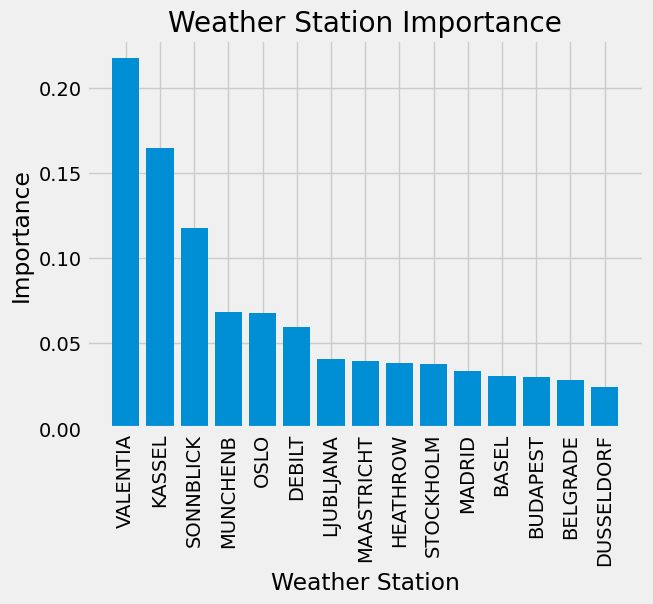

In [47]:
# Plot the results

%matplotlib inline

plt.style.use('fivethirtyeight')
print(unique_stations_list)

plt.bar(df_importance['Weather Station'], df_importance['Importance'], orientation = 'vertical')
plt.xticks(rotation='vertical')
plt.xlabel('Weather Station')
plt.ylabel('Importance')
plt.title('Weather Station Importance')

plt.show()